In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_parquet('sampling/data/whole_df_with_fe.parquet')

In [12]:
# Ensure datetime columns are in datetime format
time_cols = [
    'sent_at', 'opened_first_time_at', 'opened_last_time_at',
    'clicked_first_time_at', 'clicked_last_time_at', 'purchased_at'
]
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Sort messages by client_id and sent time
df = df.sort_values(['client_id', 'sent_at'])

In [13]:
df.shape

(1562021, 221)

# Proxy Variables

In [41]:
proxies_df = df[['message_id']]

## Expected Value

### Prior Belief (miu)

In [42]:
# 'is_opened_rate_1m', 'is_opened_rate_prev_smooth', 'is_opened_expect_gap_1m', 
# 'is_clicked_rate_1m', 'is_clicked_rate_prev_smooth', 'is_opened_rate_campaign_per_client'
# 'is_clicked_rate_campaign_per_client', 'is_purchased_rate_campaign_per_client', 
#  'is_purchased_rate_prev_smooth', time since last opened, last clicked, last purchased

In [43]:
prior_belief_df = df[['message_id',
                      'is_opened_rate_1m', 'is_opened_rate_prev_smooth', 'is_opened_expect_gap_1m', 'is_opened_rate_1m',
                      'is_clicked_rate_1m', 'is_clicked_rate_prev_smooth', 'is_purchased_rate_prev_smooth',
                      'time_since_last_open_hours', 'time_since_last_click_hours', 'time_since_last_purchase_hours'
                      ]]

In [44]:
prior_belief_df.isnull().sum().sort_values(ascending=False) / prior_belief_df.shape[0]

time_since_last_purchase_hours    0.985740
time_since_last_click_hours       0.790396
time_since_last_open_hours        0.357632
is_opened_rate_1m                 0.065303
is_opened_expect_gap_1m           0.065303
is_opened_rate_1m                 0.065303
is_clicked_rate_1m                0.065303
message_id                        0.000000
is_opened_rate_prev_smooth        0.000000
is_clicked_rate_prev_smooth       0.000000
is_purchased_rate_prev_smooth     0.000000
dtype: float64

### Prior Precision (tau)

In [45]:
# weekly open rates variance, if null fill with max variance (new clients have the lowest precision)

In [46]:
prior_precision_df = df[['message_id', 'open_rate_14d_prior_var']] 

In [47]:
prior_precision_df.isnull().sum().sort_values(ascending=False) / prior_precision_df.shape[0]

open_rate_14d_prior_var    0.05605
message_id                 0.00000
dtype: float64

<Axes: >

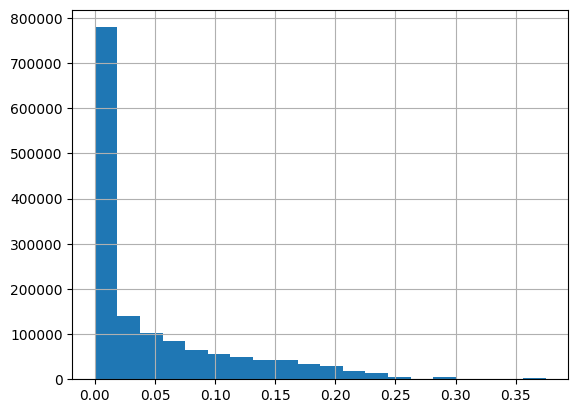

In [48]:
df['open_rate_14d_prior_var'].hist(bins=20)

In [49]:
df['open_rate_14d_prior_var'].value_counts(dropna=False)

open_rate_14d_prior_var
0.000000    505872
NaN          87551
0.234375      4337
0.296296      3919
0.375000      3247
             ...  
0.172752         1
0.182520         1
0.188614         1
0.183299         1
0.185333         1
Name: count, Length: 407989, dtype: int64

<Axes: >

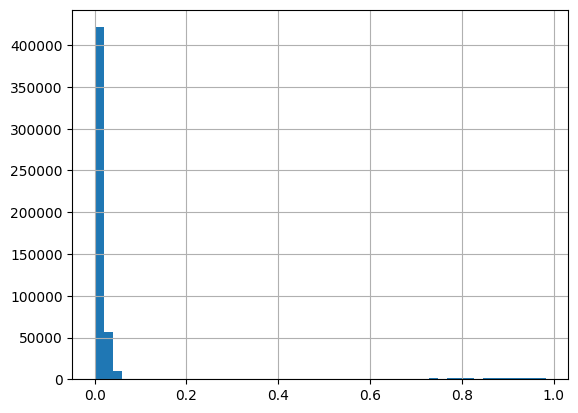

In [50]:
df[df['open_rate_14d_prior_var'] == 0]['is_opened_rate_prev_smooth'].hist(bins=50)

### Signal

In [51]:
# 'subject_with_bonuses', 'subject_with_deadline', 'subject_with_personalization', 'subject_with_saleout', 'subject_with_emoji'
# topic is happy birthday
# number of those keywords mentioned in the subject line
# number of those keywords divided on the length of the subject
# days until next holiday
#  is_opened_rate_campaign, is_clicked_rate_campaign, is_purchased_rate_campaign
# we assume that those variables describe how valuable the signal could be for a client

In [52]:
df.topic.value_counts()

topic
sale out                1527930
welcome campaign           7746
happy birthday             1888
offer after purchase       1384
event                       522
leave review                151
Name: count, dtype: int64

In [53]:
signal_df = df[['message_id', 'subject_length',
                      'subject_with_bonuses', 'subject_with_deadline', 'subject_with_personalization', 
                      'subject_with_saleout', 'subject_with_emoji', 'topic',
                      'is_opened_rate_campaign', 'is_clicked_rate_campaign', 'is_purchased_rate_campaign',
                      'days_until_next_holiday', 'days_since_last_holiday'
                      ]]

signal_df['number_of_keywords_in_subject'] = (signal_df['subject_with_bonuses'] +
                                              signal_df['subject_with_deadline'] +
                                              signal_df['subject_with_personalization'] +
                                              signal_df['subject_with_saleout'] +
                                              signal_df['subject_with_emoji']
                                            )

signal_df['keywords_compare_with_length'] = signal_df['number_of_keywords_in_subject'] / signal_df['subject_length']

signal_df['birthday_message'] = np.where(signal_df['topic'] == 'happy birthday', 1, 0)
signal_df['welcome_message'] = np.where(signal_df['topic'] == 'welcome campaign', 1, 0)
signal_df['offer_after_purchase_message'] = np.where(signal_df['topic'] == 'offer after purchase', 1, 0)


signal_df = signal_df.drop(columns=['subject_length', 'topic'])

/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_71387/4226615719.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  signal_df['number_of_keywords_in_subject'] = (signal_df['subject_with_bonuses'] +
/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_71387/4226615719.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  signal_df['keywords_compare_with_length'] = signal_df['number_of_keywords_in_subject'] / signal_df['subject_length']
/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykern

In [54]:
signal_df.columns

Index(['message_id', 'subject_with_bonuses', 'subject_with_deadline',
       'subject_with_personalization', 'subject_with_saleout',
       'subject_with_emoji', 'is_opened_rate_campaign',
       'is_clicked_rate_campaign', 'is_purchased_rate_campaign',
       'days_until_next_holiday', 'days_since_last_holiday',
       'number_of_keywords_in_subject', 'keywords_compare_with_length',
       'birthday_message', 'welcome_message', 'offer_after_purchase_message'],
      dtype='object')

In [55]:
signal_df.isnull().sum().sort_values(ascending=False)

is_opened_rate_campaign          1496
is_clicked_rate_campaign         1496
is_purchased_rate_campaign       1496
message_id                          0
subject_with_bonuses                0
subject_with_deadline               0
subject_with_personalization        0
subject_with_saleout                0
subject_with_emoji                  0
days_until_next_holiday             0
days_since_last_holiday             0
number_of_keywords_in_subject       0
keywords_compare_with_length        0
birthday_message                    0
welcome_message                     0
offer_after_purchase_message        0
dtype: int64

### Signal Precision

In [56]:
# subject length, is_email
# we assume that email notifications have higher precisions than push notifications in general.

signal_precision_df = df[['message_id', 
                      'subject_length', 'is_email'
                      ]]

In [57]:
signal_precision_df.isnull().sum()

message_id        0
subject_length    0
is_email          0
dtype: int64

## Cognitive Cost

### Baseline Cognitive Cost

In [73]:
# average time since first opens

baseline_cost_df = df[['message_id',
                       'avg_time_to_open_hours_prev',
                        'avg_time_to_click_hours_prev'
                    ]]

baseline_cost_df.isnull().sum()

message_id                            0
avg_time_to_open_hours_prev     1289927
avg_time_to_click_hours_prev    1549349
dtype: int64

### Load (Fatigue)

In [59]:
load_df = df[[
    'message_id',
    'sent_count_1m',
    'sent_count_1w', 'sent_count_1d', 
    'sent_count_email_1w', 'sent_count_email_1d',
    'avg_interval_1w', 'avg_interval_1d',
    'bulk_count_1d', 'bulk_count_1w',
    'bulk_count_1m',
    'avg_subject_len_1w', 'avg_subject_len_1d',
    'days_since_last_msg','days_since_last_bulk',
    'opened_count_1w', 'clicked_count_1w',
    'opened_count_1m_ex_1w', 'clicked_count_1m_ex_1w',
    'total_msgs', 'market_avg_msgs_6h', 'market_avg_msgs_1d',
    'market_avg_msgs_1w', 'market_avg_msgs_1m',
    'is_weekend', 'is_working_hours',
    'is_morning', 'is_afternoon',
    'is_evening', 'is_night',
    'quarter',
    'global_is_opened_rate_1w',
    'global_is_opened_rate_1m',
    'global_is_clicked_rate_1w',
    'global_is_clicked_rate_1m',
    'global_is_purchased_rate_1w',
    'global_is_purchased_rate_1m',
]]

#### Persistance

In [60]:
# count of messages for last month, excepted last week,
# number of opened messages during last month, excepted last week,
# count of bulk campaigns, total count
# market pressure during last month, excepted last week


# 'sent_count_1m', 'bulk_count_1m',
# 'opened_count_1m_ex_1w', 'clicked_count_1m_ex_1w'
# 'market_avg_msgs_1m',  'global_is_clicked_rate_1m',
# 'global_is_purchased_rate_1w', 'global_is_purchased_rate_1m'

#### Focal Firm Message Pressure

In [61]:

# 'sent_count_1w', 'sent_count_1d', 
# 'sent_count_email_1w', 'sent_count_email_1d',
#     'avg_interval_1w', 'avg_interval_1d',
#     'bulk_count_1d', 'bulk_count_1w',
#     'avg_subject_len_1w', 'avg_subject_len_1d',
#     'days_since_last_msg','days_since_last_bulk',
#     'opened_count_1w', 'clicked_count_1w'

#### Market Pressure

In [62]:
# 'total_msgs', 'market_avg_msgs_6h', 'market_avg_msgs_1d',
    # 'market_avg_msgs_1w'

#### Time related

In [63]:
# 'is_weekend', 'is_working_hours',
#     'is_morning', 'is_afternoon',
#     'is_evening', 'is_night',
#     'quarter'


# Create dummy variables, drop the first category
quarter_dummies = pd.get_dummies(load_df['quarter'], prefix='quarter', drop_first=True)

# Concatenate back to original dataframe
load_df = pd.concat([load_df, quarter_dummies], axis=1)
load_df = load_df.drop(columns = ['quarter'])

#### Event Related

In [64]:
# 'global_is_opened_rate_1w',
# 'global_is_clicked_rate_1w',
# 'global_is_purchased_rate_1w'

# Controls

In [65]:
# days since last purchase (if last purchase was recently, then the customer could not be interested in the following messages)
# customer segments (loyal, occasional, dormant)

# we need to control effects of full inbox or email providers actions against spamming (as we want to capture fatigue and 
# expectations interactions in the decision making process)

# is_soft_bounced_rate_1w
# is_soft_bounced_rate_1m
# is_hard_bounced_rate_1w
# is_hard_bounced_rate_1m
# is_blocked_rate_1w
# is_blocked_rate_1m

controls_df = df[[
        'message_id',
        'time_since_last_purchase_hours',
        'is_soft_bounced_rate_1w',
        'is_soft_bounced_rate_1m',
        'is_hard_bounced_rate_1w',
        'is_hard_bounced_rate_1m',
        'is_blocked_rate_1w',
        'is_blocked_rate_1m'
]] 

In [66]:
controls_df.isnull().sum()

message_id                              0
time_since_last_purchase_hours    1539746
is_soft_bounced_rate_1w                 1
is_soft_bounced_rate_1m                 1
is_hard_bounced_rate_1w                 1
is_hard_bounced_rate_1m                 1
is_blocked_rate_1w                      1
is_blocked_rate_1m                      1
dtype: int64

# Combining

In [75]:
model_df = proxies_df.merge(prior_belief_df, on='message_id').merge(
                            prior_precision_df, on='message_id').merge(
                            signal_df, on='message_id').merge(
                            signal_precision_df, on='message_id').merge(
                            baseline_cost_df, on='message_id').merge(
                            load_df, on='message_id').merge(
                            controls_df, on='message_id')


In [76]:
model_df.shape

(1562021, 76)

In [78]:
proxies_df.shape

(1562021, 1)